In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import VarianceThreshold

import warnings
import sklearn
from scipy import stats
from matplotlib.patches import Rectangle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
import sklearn.model_selection as model_selection
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest,chi2

# 1.read CSV file

In [2]:
data = pd.read_csv('GuestSatisfactionPrediction.csv')

C:\Users\HP\AppData\Local\Temp\ipykernel_30292\2100762051.py:1: DtypeWarning: Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('GuestSatisfactionPrediction.csv')


In [3]:
data.shape

(8724, 69)

In [4]:

data.head()

,id,listing_url,name,summary,space,description,neighborhood_overview,notes,transit,access,...,number_of_stays,first_review,last_review,review_scores_rating,requires_license,instant_bookable,is_business_travel_ready,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification
0,21514496,https://www.airbnb.com/rooms/21514496,PRIVATE BEDROOM DOWNTOWN 2 BED/ 2 BATH #5,Beautiful 2 bedroom 2 bathroom furnished apart...,Each apartment is fully furnished and consists...,Beautiful 2 bedroom 2 bathroom furnished apart...,NaN,***Note that the pictures on the website may o...,NaN,NaN,...,2,11/17/2017,11/17/2017,80.0,f,f,f,strict_14_with_grace_period,f,f
1,990185,https://www.airbnb.com/rooms/990185,4 bed/2 ba Family Retreat in SD,We feel our house is a great place for a famil...,Our house is ideal for large families or group...,We feel our house is a great place for a famil...,Neighborhood Mira Mesa is a culturally diverse...,NaN,NaN,Our guests may use the BBQ grill.,...,26,8/2/2013,7/31/2019,97.0,f,f,f,moderate,f,f
2,19878244,https://www.airbnb.com/rooms/19878244,San Diego Dream Villa,"Zen, Luxury and the Best Location in Americas ...","San Diego Dream Villa, this unique and luxurio...","Zen, Luxury and the Best Location in Americas ...",This amazing house is located within a few min...,Im always available to make your trip experien...,"If you are bringing your car, remember that SD...",A couple of days before your arrival you will ...,...,170,7/23/2017,7/16/2019,98.0,f,f,f,strict_14_with_grace_period,f,f
3,24561458,https://www.airbnb.com/rooms/24561458,Studio with Piazza View in Downtown Little Italy,Start the day with breakfast on the sunny pati...,"Newly built, this beautiful studio is located ...",Start the day with breakfast on the sunny pati...,"Spend the day at the zoo in Balboa Park, or ex...",The apartment is located on the Piazza Della F...,"MTS, Train, and Trolly are close by. The airpo...",You will not be sharing the apartment with any...,...,212,5/1/2018,8/3/2019,98.0,f,t,f,moderate,f,f
4,32269829,https://www.airbnb.com/rooms/32269829,Beachside Retreat w/ Private Rooftop Deck w/ V...,This is a 2 bedroom/1 bathroom beachside unit...,Beach living at its finest! The highlight of ...,This is a 2 bedroom/1 bathroom beachside unit...,Mission Beach is an amazing coastal community ...,NaN,The Boardwalk and Bayside Walk are wonderful w...,This is a private home that is part of a typic...,...,2,6/30/2019,6/30/2019,100.0,f,t,f,strict_14_with_grace_period,f,f


In [5]:
data.columns

Index(['id', 'listing_url', 'name', 'summary', 'space', 'description',
       'neighborhood_overview', 'notes', 'transit', 'access', 'interaction',
       'house_rules', 'thumbnail_url', 'host_id', 'host_url', 'host_name',
       'host_since', 'host_location', 'host_about', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_has_profile_pic',
       'host_identity_verified', 'street', 'neighbourhood',
       'neighbourhood_cleansed', 'city', 'state', 'zipcode', 'market',
       'smart_location', 'country_code', 'country', 'latitude', 'longitude',
       'is_location_exact', 'property_type', 'room_type', 'accommodates',
       'bathrooms', 'bedrooms', 'beds', 'bed_type', 'amenities', 'square_feet',
       'nightly_price', 'price_per_stay', 'security_deposit', 'cleaning_fee',
       'guests_included', 'extra_people', 'minimum_nights', 'maximum_nights',

In [6]:
data.describe()

,id,thumbnail_url,host_id,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,square_feet,guests_included,minimum_nights,maximum_nights,number_of_reviews,number_of_stays,review_scores_rating
count,8.724000e+03,0.0,8.724000e+03,0.0,8723.00000,8723.00000,8724.000000,8724.000000,8724.000000,8723.000000,8721.000000,8721.000000,106.000000,8724.000000,8724.000000,8724.000000,8724.000000,8724.000000,8724.000000
mean,2.061576e+07,NaN,7.217782e+07,NaN,36.63900,36.63900,32.767648,-117.181171,4.478450,1.477645,1.622176,2.383213,780.122642,2.385488,3.882164,612.218134,41.851674,83.703347,95.298945
std,1.022036e+07,NaN,7.192548e+07,NaN,148.16393,148.16393,0.063700,0.064124,2.966026,0.867093,1.172510,1.854677,581.604721,2.309945,13.271263,1532.434921,63.566724,127.133448,6.871417
min,6.000000e+00,NaN,2.900000e+01,NaN,0.00000,0.00000,32.531380,-117.281240,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,2.000000,20.000000
25%,1.331246e+07,NaN,1.281344e+07,NaN,1.00000,1.00000,32.725623,-117.245445,2.000000,1.000000,1.000000,1.000000,500.000000,1.000000,1.000000,29.000000,5.000000,10.000000,94.000000
50%,2.122258e+07,NaN,4.407444e+07,NaN,2.00000,2.00000,32.756810,-117.168045,4.000000,1.000000,1.000000,2.000000,600.000000,1.000000,2.000000,365.000000,17.000000,34.000000,97.000000
75%,2.896445e+07,NaN,1.148944e+08,NaN,9.00000,9.00000,32.797730,-117.139930,6.000000,2.000000,2.000000,3.000000,1000.000000,3.000000,3.000000,1125.000000,52.000000,104.000000,100.000000
max,3.774504e+07,NaN,2.843016e+08,NaN,1737.00000,1737.00000,33.086070,-116.935990,24.000000,27.500000,10.000000,22.000000,3800.000000,24.000000,800.000000,99999.000000,641.000000,1282.000000,100.000000


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8724 entries, 0 to 8723
Data columns (total 69 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                8724 non-null   int64  
 1   listing_url                       8724 non-null   object 
 2   name                              8724 non-null   object 
 3   summary                           8497 non-null   object 
 4   space                             7105 non-null   object 
 5   description                       8630 non-null   object 
 6   neighborhood_overview             6490 non-null   object 
 7   notes                             5215 non-null   object 
 8   transit                           5975 non-null   object 
 9   access                            6011 non-null   object 
 10  interaction                       6164 non-null   object 
 11  house_rules                       6754 non-null   object 
 12  thumbn

# 2. Show NULL and fill it

In [8]:
print(data.isnull().sum())

id                                     0
listing_url                            0
name                                   0
summary                              227
space                               1619
                                    ... 
instant_bookable                       0
is_business_travel_ready               0
cancellation_policy                    0
require_guest_profile_picture          0
require_guest_phone_verification       0
Length: 69, dtype: int64


<Axes: >

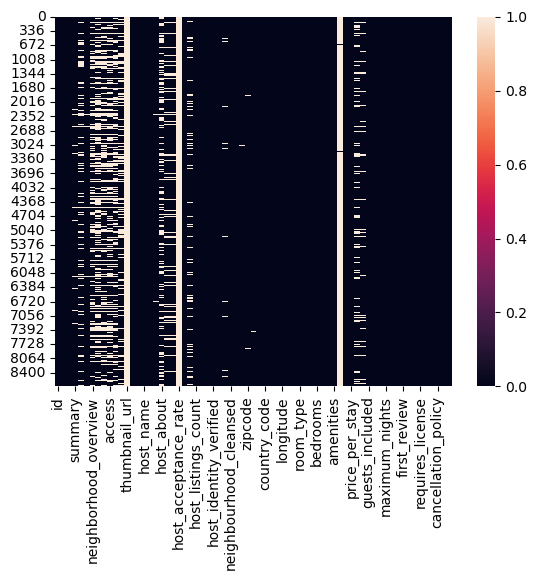

In [9]:
sns.heatmap(data.isnull())

In [10]:
missing_summary=(data.summary.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in summary is \t\t  :",missing_summary)

missing_space=(data.space.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in space is \t\t  :",missing_space)

missing_description=(data.description.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in description is \t  :",missing_description)

missing_neighborhood_overview=(data.neighborhood_overview.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in neighborhood_overview is :",missing_neighborhood_overview)

missing_notes=(data.notes.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in notes is \t\t  :",missing_notes)

missing_transit=(data.transit.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in transit is \t\t  :",missing_transit)

missing_access=(data.access.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in access is \t\t  :",missing_access)

missing_interaction=(data.interaction.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in interaction is \t  :",missing_interaction)

missing_house_rules=(data.house_rules.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in house_rules is \t  :",missing_house_rules)

missing_thumbnail_url=(data.thumbnail_url.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in thumbnail_url is \t  :",missing_thumbnail_url)

missing_host_location=(data.host_location.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in host_location is \t  :",missing_host_location)

missing_host_about=(data.host_about.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in host_about is \t\t  :",missing_host_about)

missing_host_response_time=(data.host_response_time.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in host_response_time is \t  :",missing_host_response_time)

missing_host_response_rate=(data.host_response_rate.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in host_response_rate is \t  :",missing_host_response_rate)

missing_host_acceptance_rate=(data.host_acceptance_rate.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in host_acceptance_rate is  :",missing_host_acceptance_rate)

missing_host_neighbourhood=(data.host_neighbourhood.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in host_neighbourhood is \t  :",missing_host_neighbourhood)

missing_neighbourhood =(data.neighbourhood .isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in neighbourhood is \t  :",missing_neighbourhood)

missing_zipcode=(data.zipcode.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in zipcode is \t\t  :",missing_zipcode)

missing_market=(data.market.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in market is \t\t  :",missing_market)

missing_square_feet=(data.square_feet.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in square_feet is \t  :",missing_square_feet)

missing_security_deposit=(data.security_deposit.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in security_deposit is \t  :",missing_security_deposit)

missing_cleaning_fee=(data.cleaning_fee.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information in cleaning_fee is \t  :",missing_cleaning_fee)

The precentage of missing information in summary is 		  : 2.6020174232003668
The precentage of missing information in space is 		  : 18.558000917010546
The precentage of missing information in description is 	  : 1.0774873911049978
The precentage of missing information in neighborhood_overview is : 25.607519486474096
The precentage of missing information in notes is 		  : 40.22237505731316
The precentage of missing information in transit is 		  : 31.510774873911053
The precentage of missing information in access is 		  : 31.098120128381478
The precentage of missing information in interaction is 	  : 29.344337459880787
The precentage of missing information in house_rules is 	  : 22.58138468592389
The precentage of missing information in thumbnail_url is 	  : 100.0
The precentage of missing information in host_location is 	  : 0.16047684548372307
The precentage of missing information in host_about is 		  : 28.220999541494727
The precentage of missing information in host_response_time is 

In [11]:
((data.isnull().sum() / data.shape[0])*100).sort_values(ascending=False)

host_acceptance_rate                100.000000
thumbnail_url                       100.000000
square_feet                          98.784961
notes                                40.222375
transit                              31.510775
                                       ...    
is_location_exact                     0.000000
property_type                         0.000000
room_type                             0.000000
accommodates                          0.000000
require_guest_phone_verification      0.000000
Length: 69, dtype: float64

In [12]:
#drop colomns
to_drop = [
    "thumbnail_url",       # 100% missing
    "host_acceptance_rate",# 100% missing
    "square_feet",         # 98.8% missing
    "name",
    "host_name",
    "id",
    "listing_url",
    "host_url",
    "host_id",
    
    "country_code",  #the same country
    "smart_location" #the same as of city + state
]
data = data.drop(columns=to_drop)

In [13]:
data['nightly_price'] = data['nightly_price'].replace('[\$,]', '', regex=True).astype(float)
data['price_per_stay'] = data['price_per_stay'].replace('[\$,]', '', regex=True).astype(float)
data['security_deposit'] = data['security_deposit'].replace('[\$,]', '', regex=True).astype(float)
data['cleaning_fee'] = data['cleaning_fee'].replace('[\$,]', '', regex=True).astype(float)
data['extra_people'] = data['extra_people'].replace('[\$,]', '', regex=True).astype(float)

In [14]:
data['host_response_rate'] = data['host_response_rate'].replace('[\%,]', '', regex=True).astype(float)

In [15]:
data['first_review'] = pd.to_datetime(data['first_review'], errors='coerce')
data['first_review'] = (pd.to_datetime("today") - data['first_review']).dt.days / 365
data['last_review'] = pd.to_datetime(data['last_review'], errors='coerce')
data['last_review'] = (pd.to_datetime("today") - data['last_review']).dt.days / 365
data['host_since'] = pd.to_datetime(data['host_since'], errors='coerce')
data['host_since'] = (pd.to_datetime("today") - data['host_since']).dt.days / 365

In [16]:
data['zipcode'] = data['zipcode'].replace('-', '', regex=True).astype(float)

In [17]:
# fill by median
meadian_cols=['beds','bathrooms','bedrooms','cleaning_fee','security_deposit','host_total_listings_count','host_listings_count','host_response_rate','host_since']
data[meadian_cols]=data[meadian_cols].fillna(data[meadian_cols].median())

In [18]:
data['city'] = data['city'].str.split(',', expand=True)[0]

#fill by median of the same city
data['zipcode']=data['zipcode'].fillna(data.groupby(['city'])['zipcode'].transform('median'))

In [19]:
#fill by mode 
cols_to_mode = ['host_response_time','neighbourhood','market','host_location','host_neighbourhood','host_identity_verified','host_has_profile_pic','host_is_superhost']
for col in cols_to_mode:
    if data[col].mode().empty:
        data[col] = data[col].fillna('Unknown')
    else:
        mode_val = data[col].mode()[0]
        data[col] = data[col].fillna(mode_val)
        

In [20]:
#fill be valy refer to it
null_idx = data.index[data['state'].isna()]
# print(null_idx)
# print(data['state'][null_idx])
data['state'][null_idx]=data['street'][null_idx].str.split(',', expand=True)[0]
# print(data['state'][null_idx])
data = data.drop(columns="street")    #the same of city + state + country

C:\Users\HP\AppData\Local\Temp\ipykernel_30292\1035588039.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['state'][null_idx]=data['street'][null_idx].str.split(',', expand=True)[0]


In [21]:
missing_cleaning_beds=(data.beds.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information after fill in cleaning_beds is \t  :",missing_cleaning_beds)
missing_cleaning_bathrooms=(data.bathrooms.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information after fill in bathrooms is \t  :",missing_cleaning_bathrooms)
missing_nightly_price=(data.nightly_price.isnull().sum() / data.shape[0]) * 100
print("The precentage of missing information after fill in nightly_price is \t  :",missing_nightly_price)

print("The precentage of missing information after fill in host_response_time is \t  :",(data.host_response_time.isnull().sum() / data.shape[0]) * 100)
print("The precentage of missing information after fill in neighbourhood is \t  :",(data.neighbourhood.isnull().sum() / data.shape[0]) * 100)
print("The precentage of missing information after fill in state  is \t  :",(data.state.isnull().sum() / data.shape[0]) * 100)
print("The precentage of missing information after fill in market  is \t  :",(data.market.isnull().sum() / data.shape[0]) * 100)
print("The precentage of missing information after fill in host_location  is \t  :",(data.host_location.isnull().sum() / data.shape[0]) * 100)
print("The precentage of missing information after fill in host_neighbourhood  is \t  :",(data.host_neighbourhood.isnull().sum() / data.shape[0]) * 100)


The precentage of missing information after fill in cleaning_beds is 	  : 0.0
The precentage of missing information after fill in bathrooms is 	  : 0.0
The precentage of missing information after fill in nightly_price is 	  : 0.0
The precentage of missing information after fill in host_response_time is 	  : 0.0
The precentage of missing information after fill in neighbourhood is 	  : 0.0
The precentage of missing information after fill in state  is 	  : 0.0
The precentage of missing information after fill in market  is 	  : 0.0
The precentage of missing information after fill in host_location  is 	  : 0.0
The precentage of missing information after fill in host_neighbourhood  is 	  : 0.0


# 3. Check outliers in data and identify it

In [22]:
numerical_cols = data.select_dtypes(include='number').columns
plot_cols=numerical_cols.difference(['zipcode'])
numerical_cols = numerical_cols.difference(['review_scores_rating'])

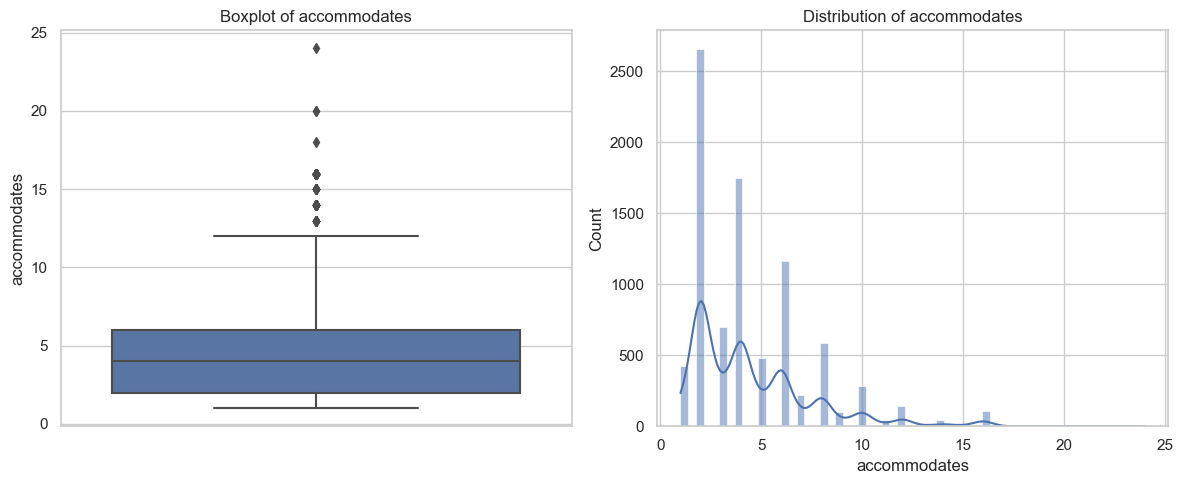

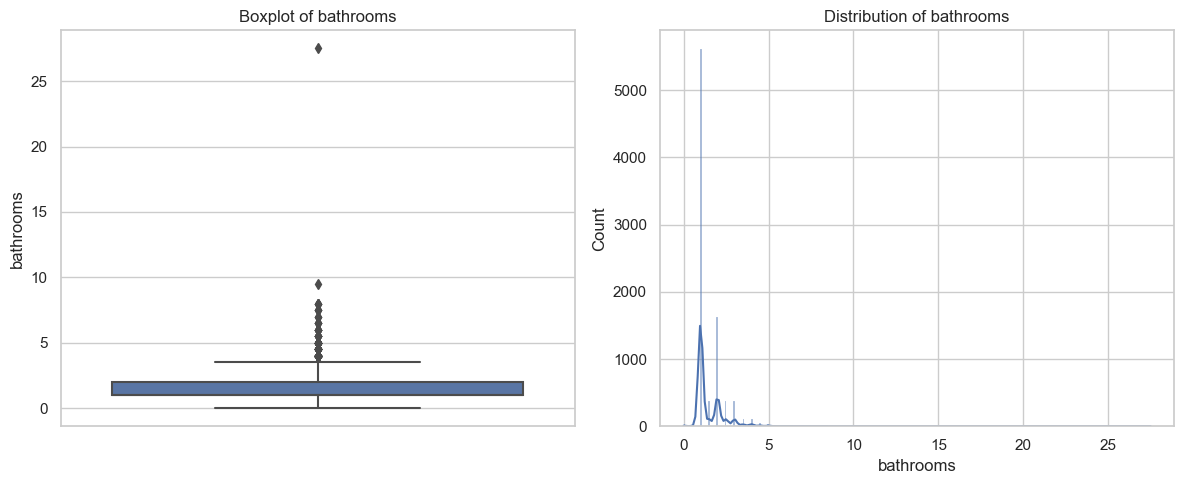

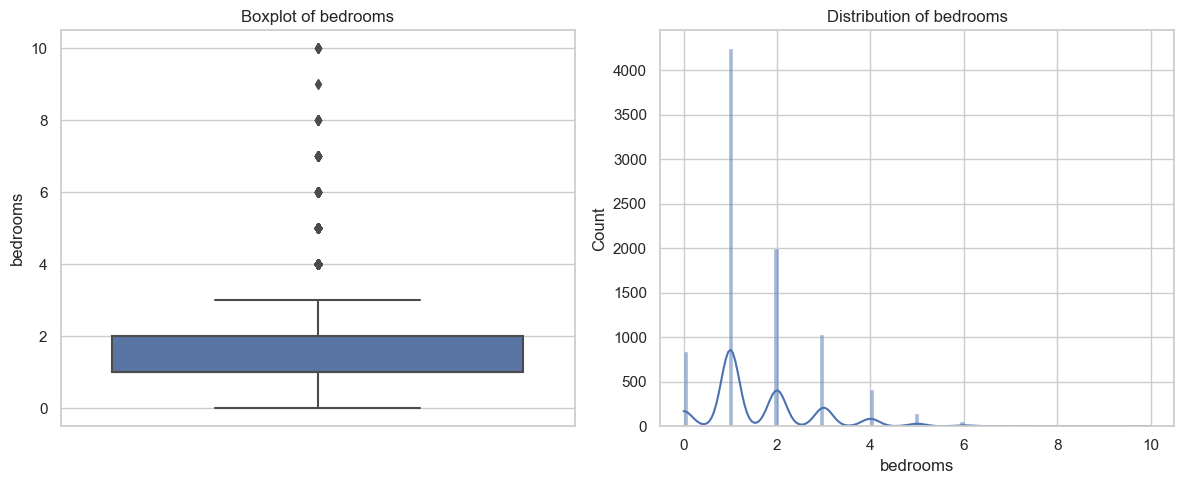

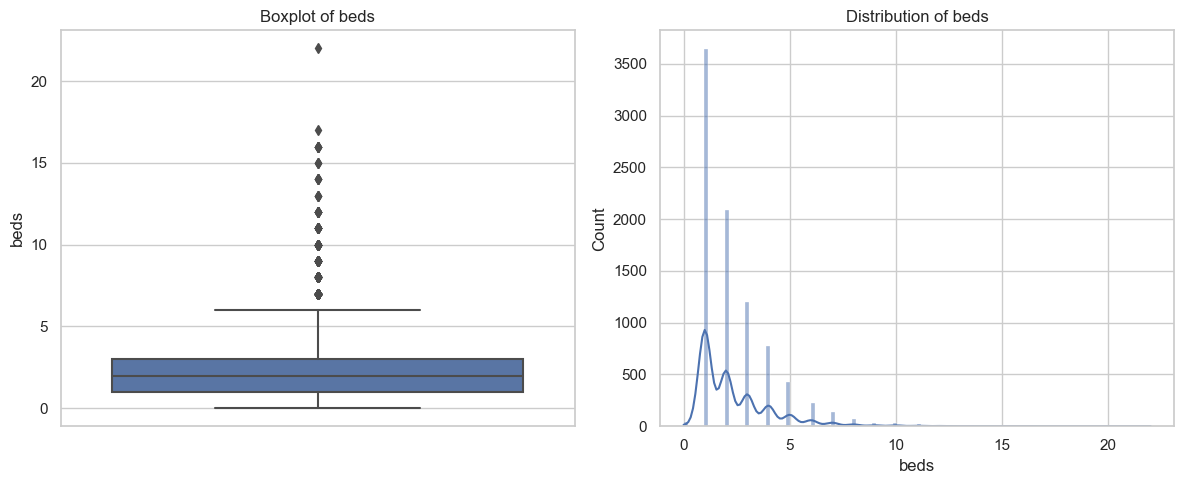

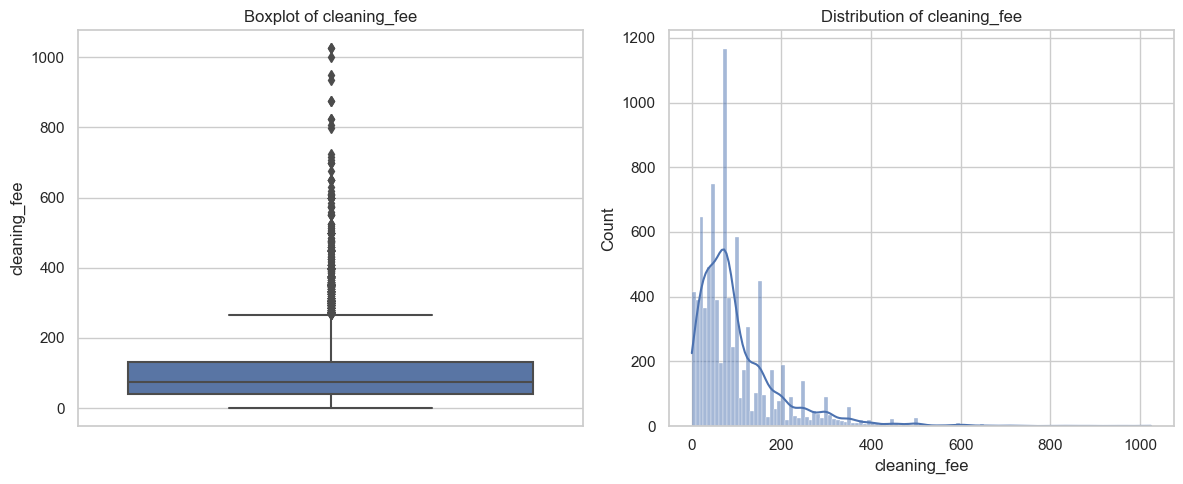

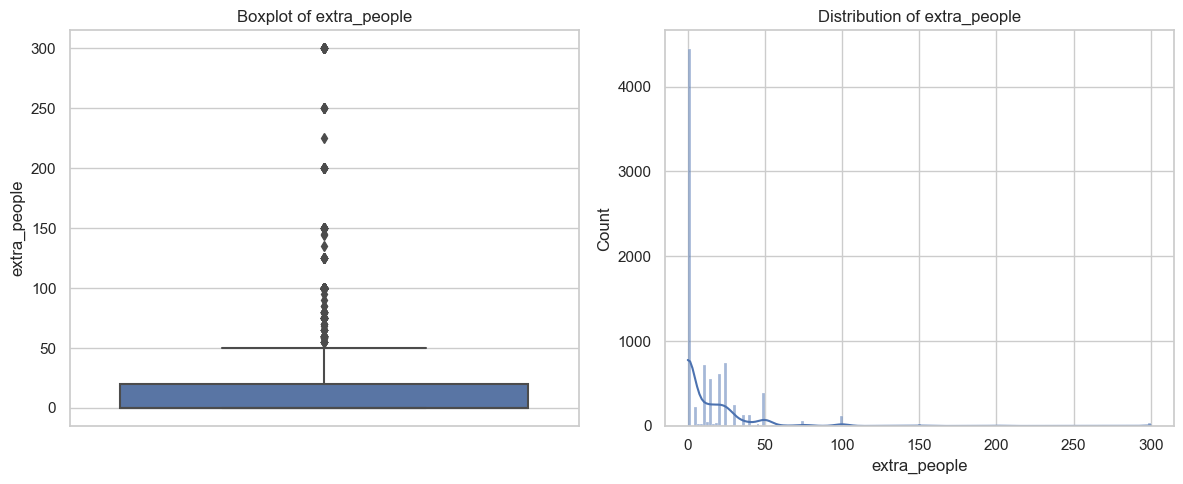

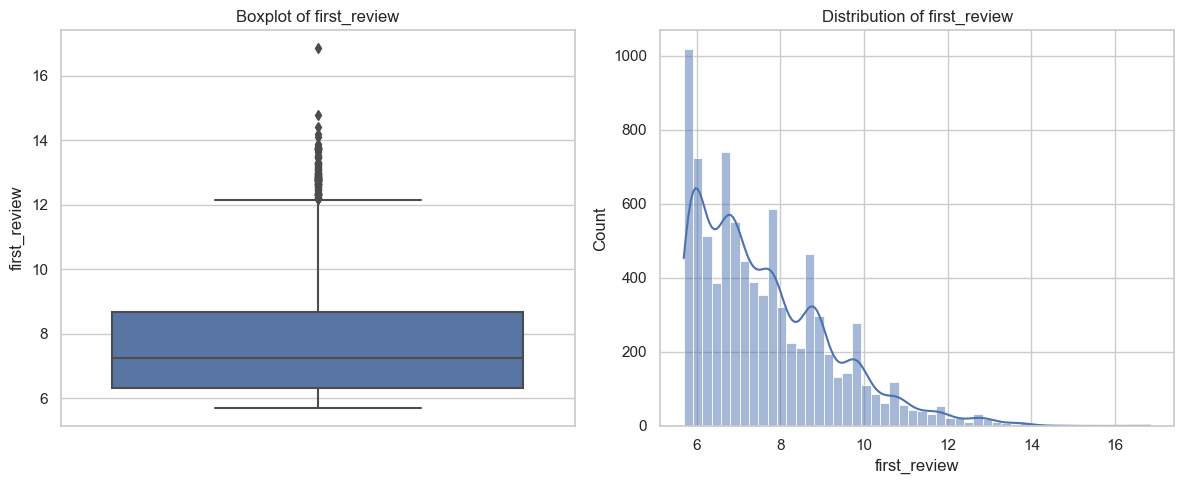

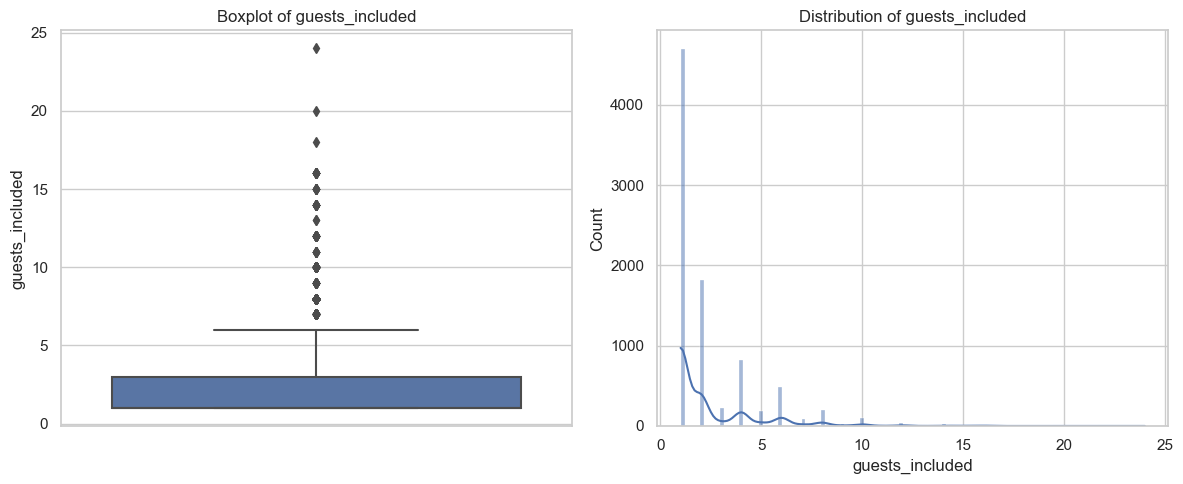

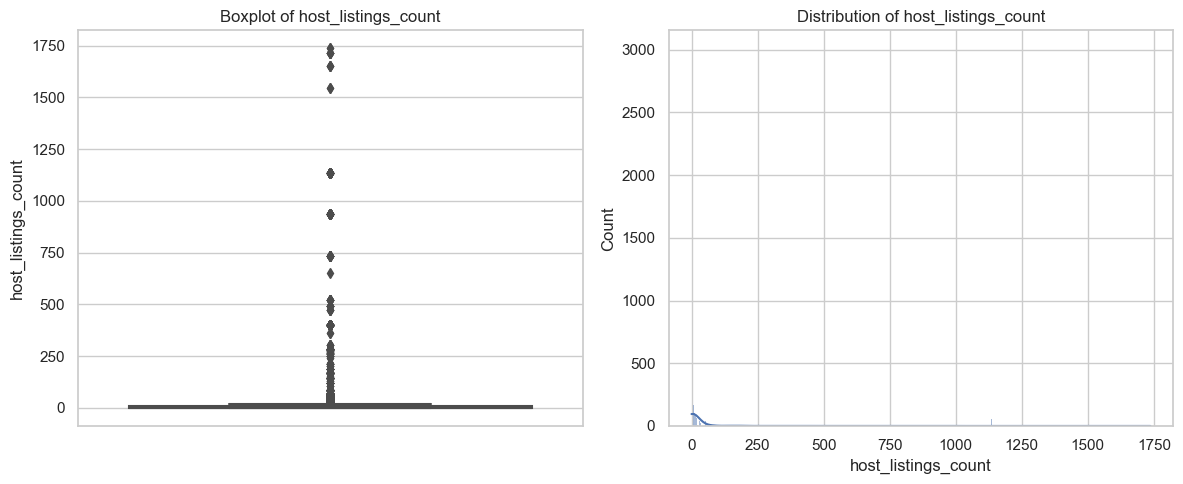

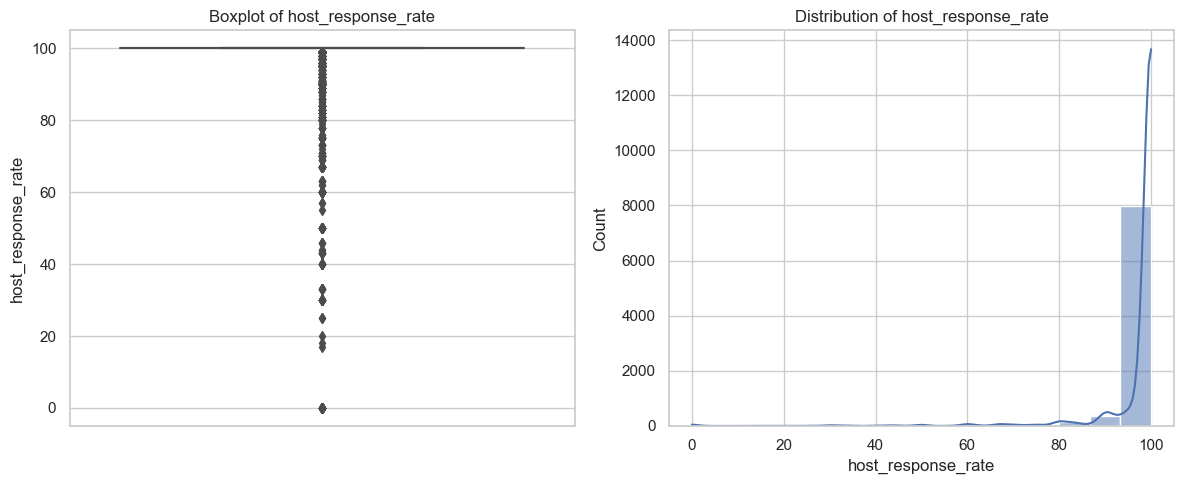

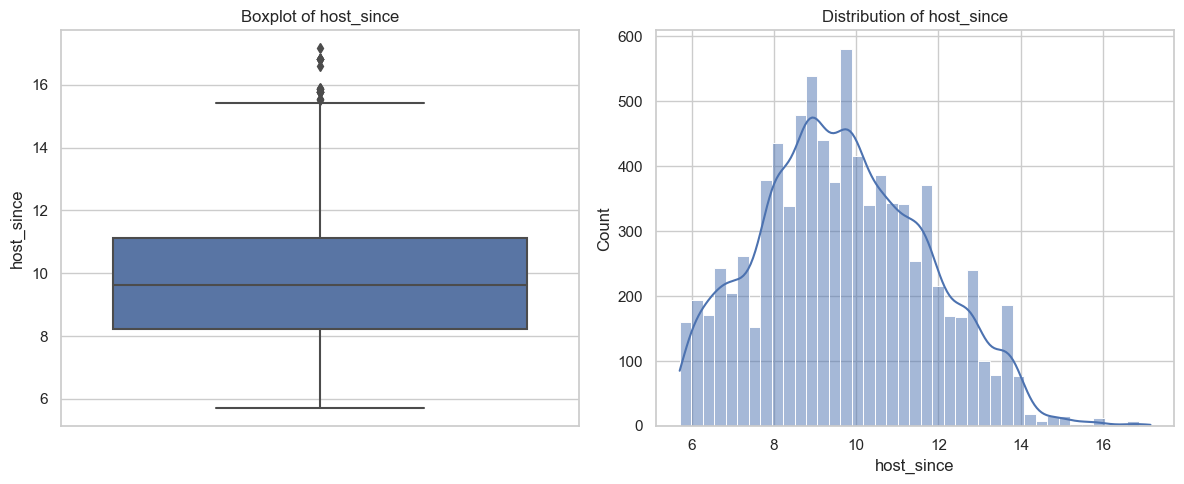

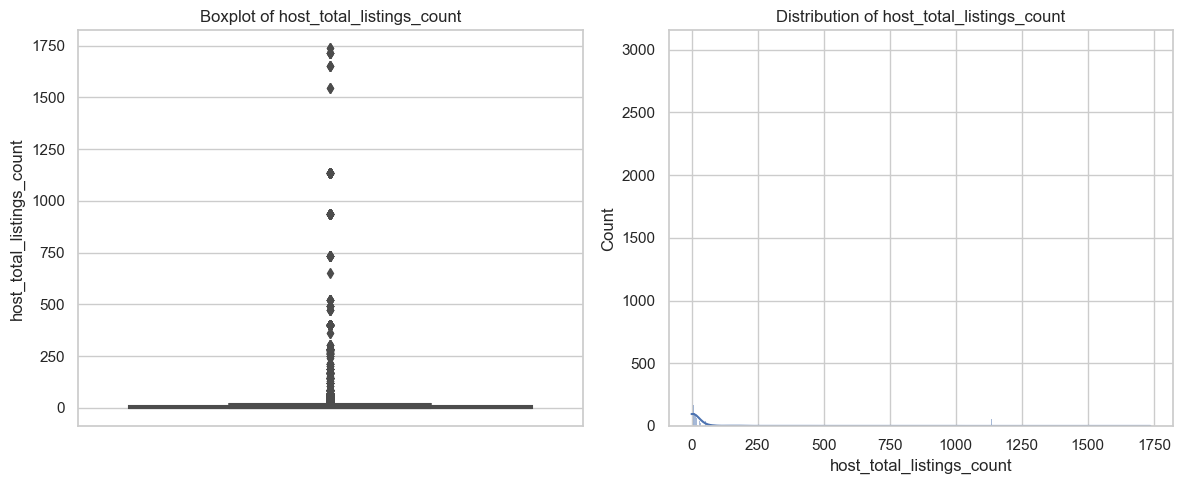

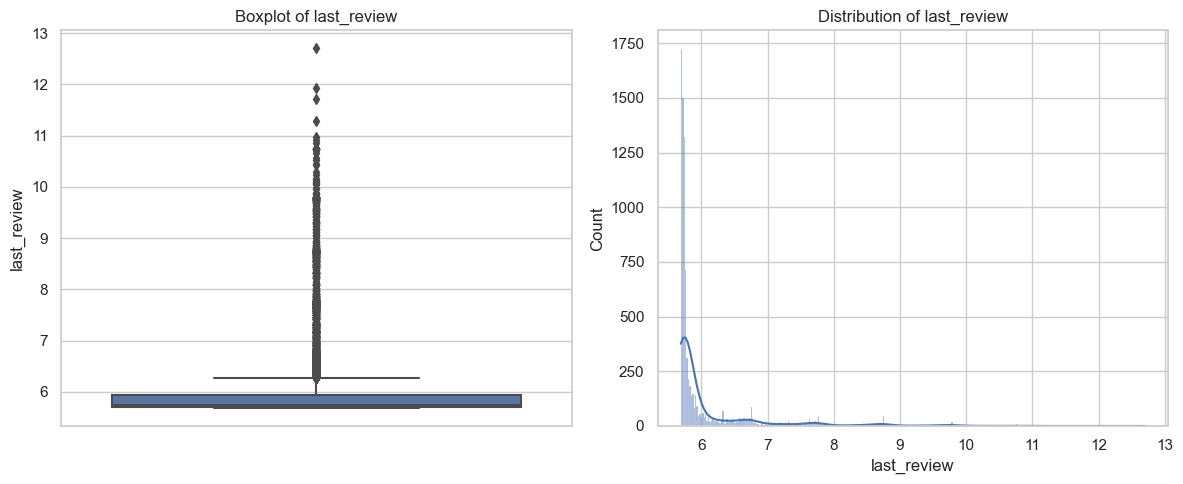

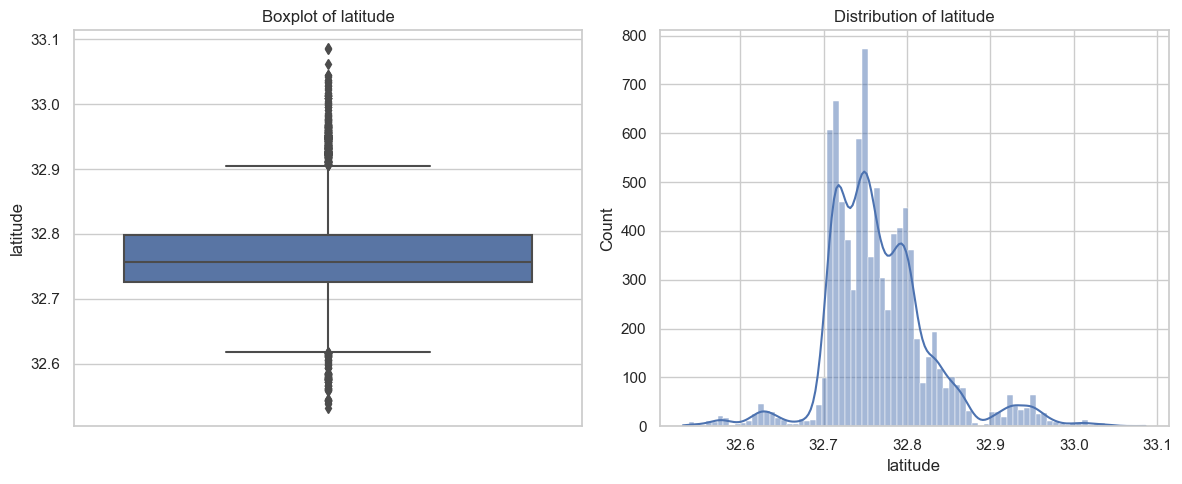

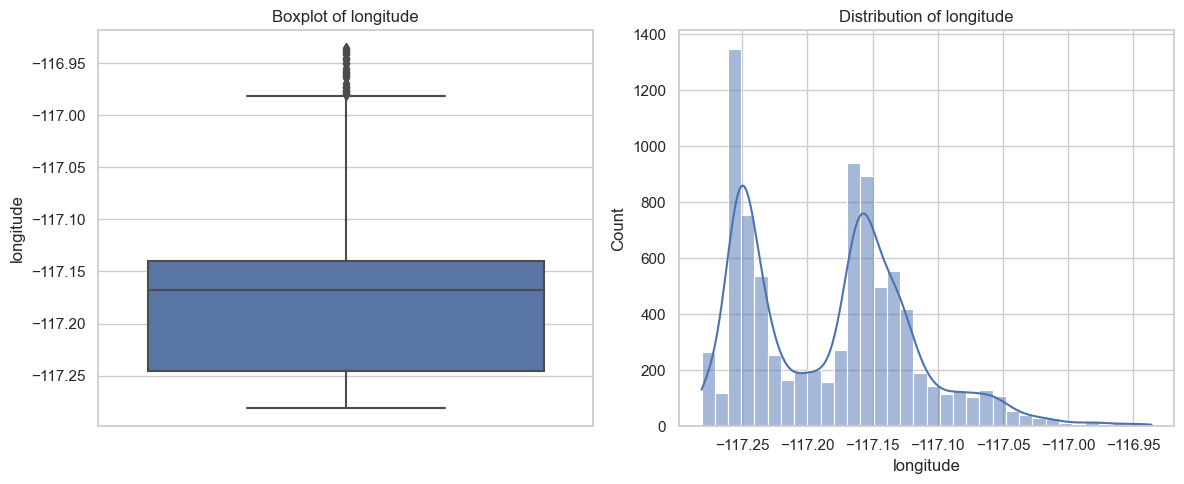

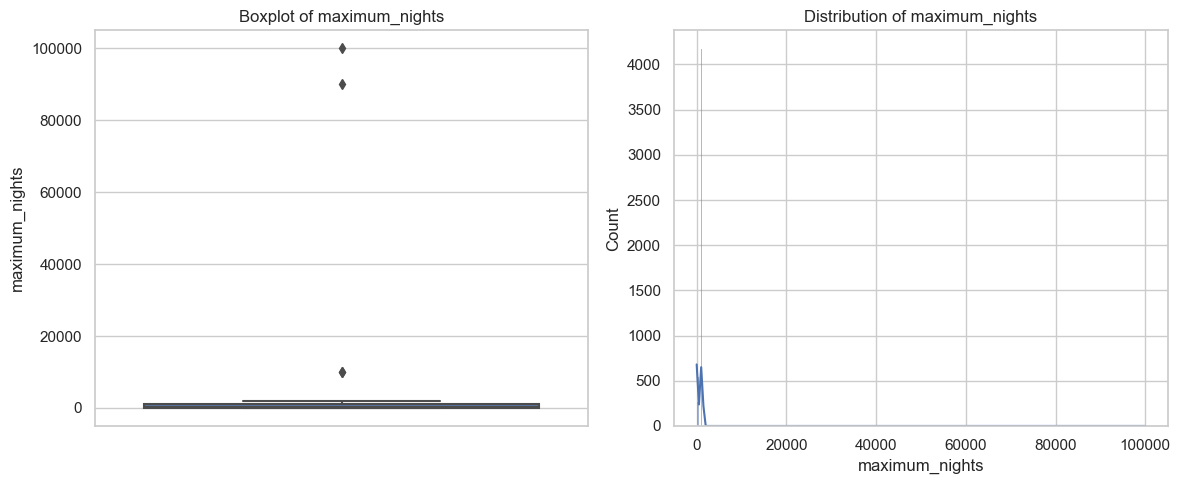

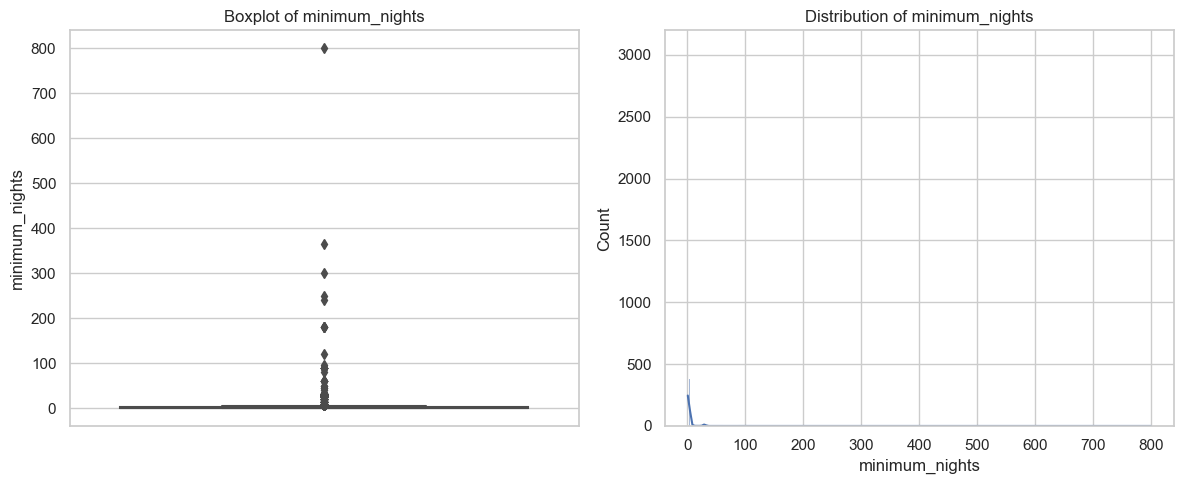

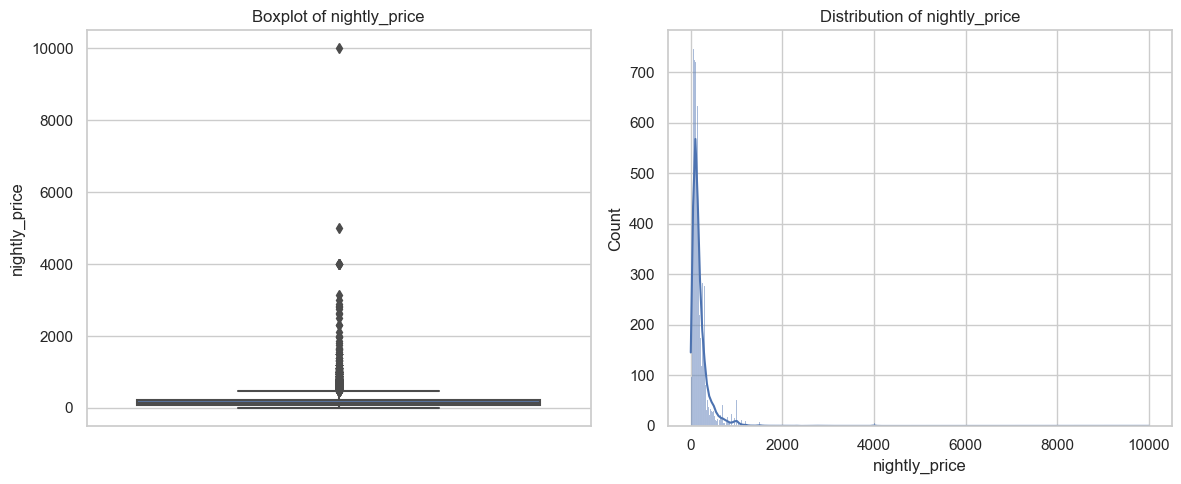

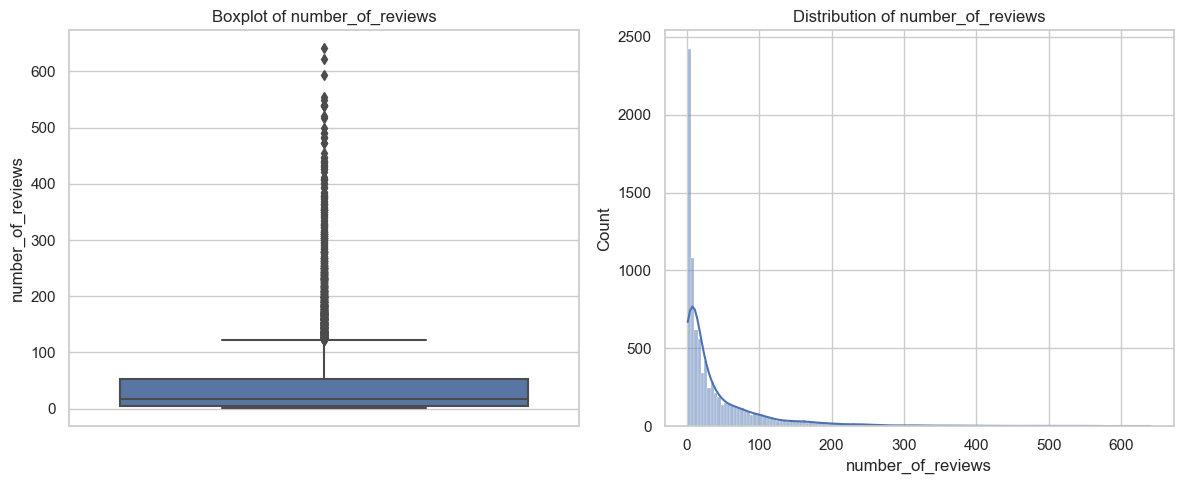

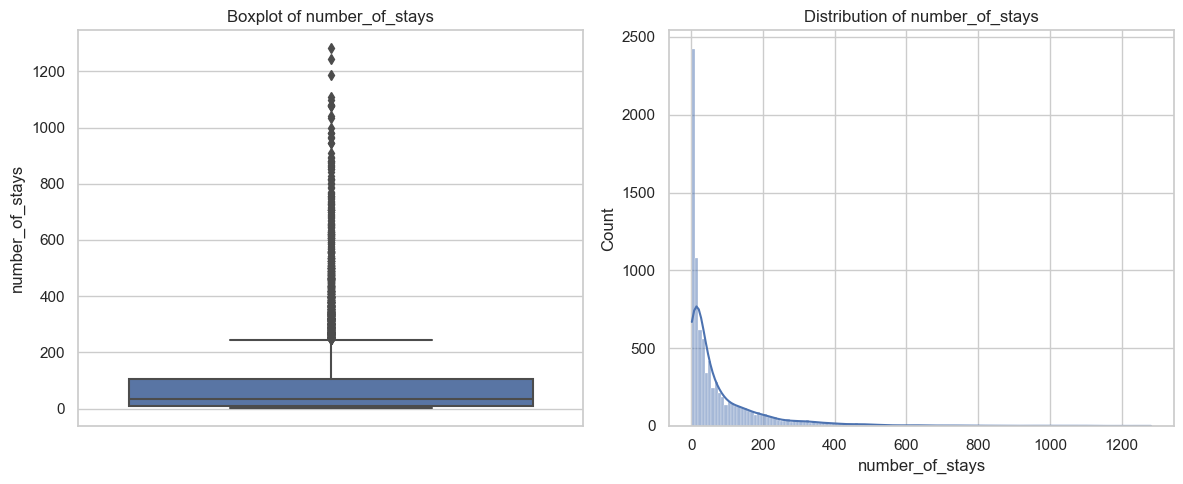

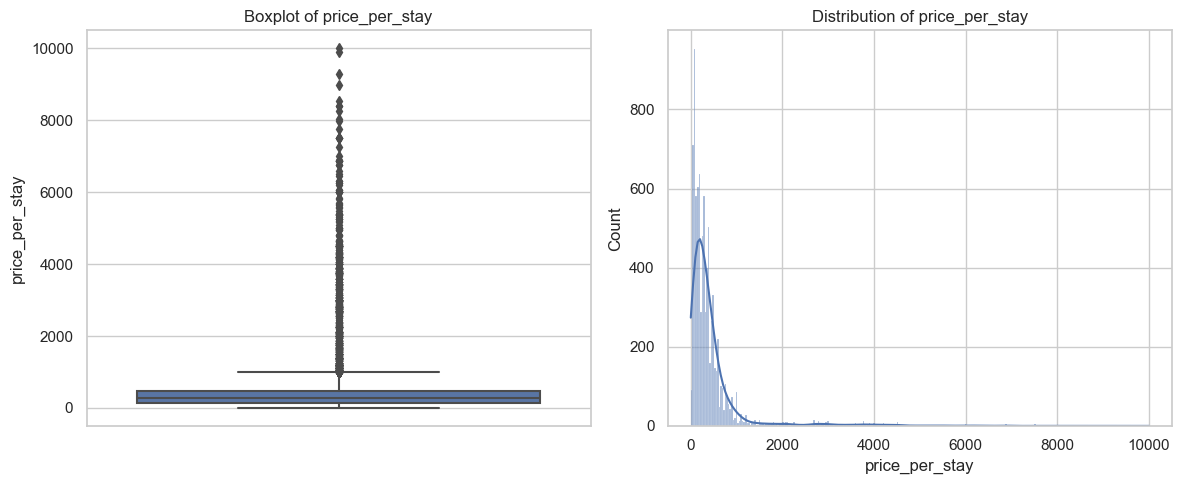

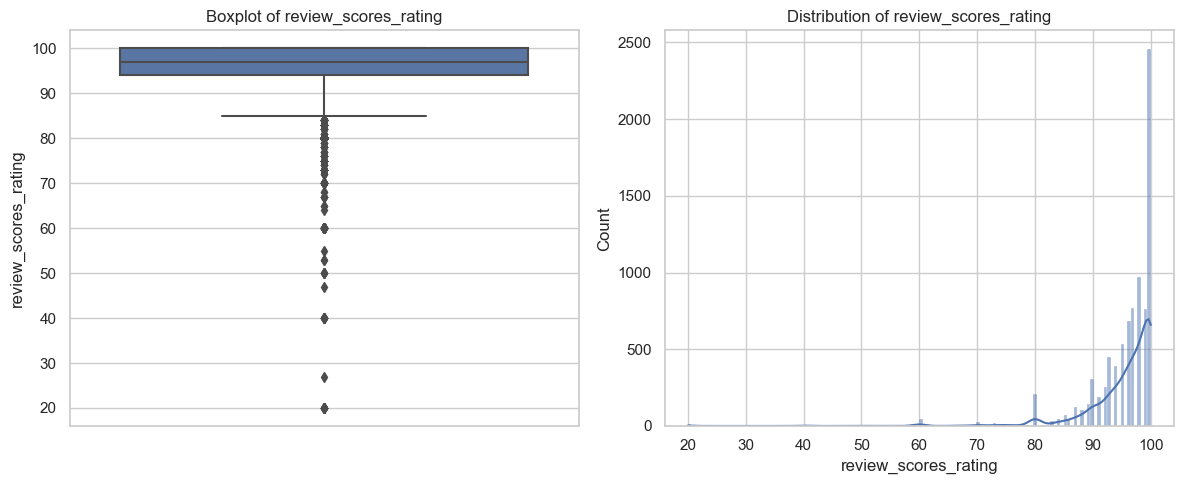

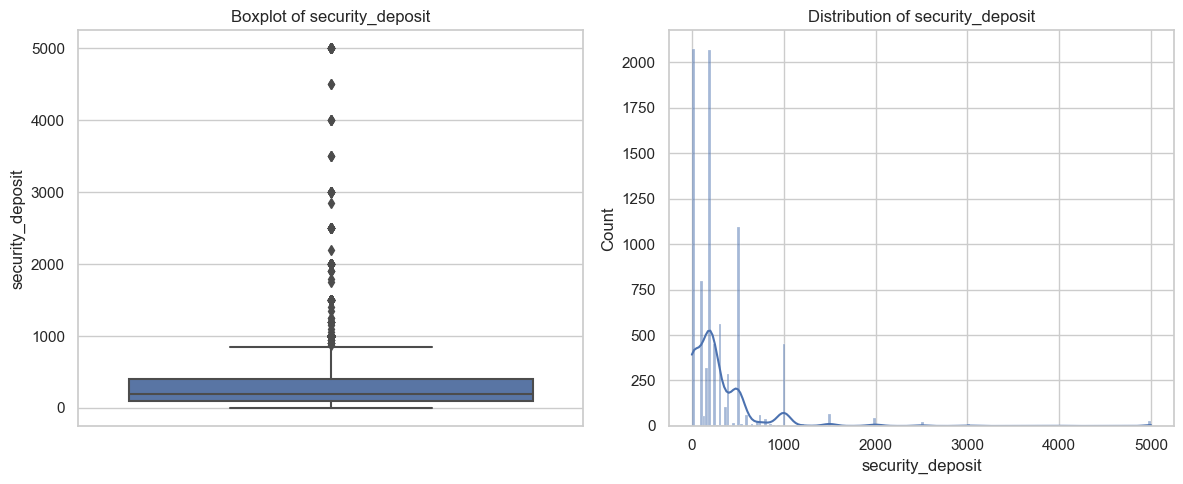

In [23]:
# Set style
sns.set(style="whitegrid")

# Create plots
for col in plot_cols:
    plt.figure(figsize=(12, 5))

    # Boxplot
    plt.subplot(1, 2, 1)
    sns.boxplot(y=data[col])
    plt.title(f'Boxplot of {col}')

    # Distplot
    plt.subplot(1, 2, 2)
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')

    plt.tight_layout()
    plt.show()

In [24]:
for col in numerical_cols:
    # calculate interquartile range
    q25, q75 = np.percentile(data[col], 25), np.percentile(data[col], 75)
    iqr = q75 - q25
    # calculate the outlier cutoff
    cut_off = iqr * 1.5
    lower, upper = q25 - cut_off, q75 + cut_off
    # identify outliers
    outliers = ( ( data[col] < lower) | (data[col] > upper) )
    index_label = data[outliers].index
    print(f'Number of outliers in {col}: {len(index_label)}')
   # ds.drop(index_label, inplace=True)

Number of outliers in accommodates: 179
Number of outliers in bathrooms: 219
Number of outliers in bedrooms: 627
Number of outliers in beds: 317
Number of outliers in cleaning_fee: 575
Number of outliers in extra_people: 318
Number of outliers in first_review: 125
Number of outliers in guests_included: 504
Number of outliers in host_listings_count: 1301
Number of outliers in host_response_rate: 1700
Number of outliers in host_since: 25
Number of outliers in host_total_listings_count: 1301
Number of outliers in last_review: 1635
Number of outliers in latitude: 521
Number of outliers in longitude: 46
Number of outliers in maximum_nights: 4
Number of outliers in minimum_nights: 629
Number of outliers in nightly_price: 687
Number of outliers in number_of_reviews: 755
Number of outliers in number_of_stays: 755
Number of outliers in price_per_stay: 653
Number of outliers in security_deposit: 671
Number of outliers in zipcode: 1458


In [25]:
# num_col = (ds.columns).to_list()
# num_col = num_col[0:]

def outliers(ds, column):
    Q1 = ds[column].quantile(0.25)
    Q3 = ds[column].quantile(0.75)
    IQR = Q3-Q1
    lower_bound = Q1-1.5*IQR
    upper_bound = Q3+1.5*IQR

    for i in range(len(ds)):
        if ds[column].iloc[i] > upper_bound:
            ds[column].iloc[i] = upper_bound
        if ds[column].iloc[i] < lower_bound:
            ds[column].iloc[i] = lower_bound
            
for feature in numerical_cols:
    outliers(data, feature)


C:\Users\HP\AppData\Local\Temp\ipykernel_30292\1643658973.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds[column].iloc[i] = upper_bound
C:\Users\HP\AppData\Local\Temp\ipykernel_30292\1643658973.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds[column].iloc[i] = upper_bound
C:\Users\HP\AppData\Local\Temp\ipykernel_30292\1643658973.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds[column].iloc[i] = upper_bound
C:\User

C:\Users\HP\AppData\Local\Temp\ipykernel_30292\1643658973.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds[column].iloc[i] = upper_bound
C:\Users\HP\AppData\Local\Temp\ipykernel_30292\1643658973.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds[column].iloc[i] = upper_bound
C:\Users\HP\AppData\Local\Temp\ipykernel_30292\1643658973.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds[column].iloc[i] = upper_bound
C:\User

C:\Users\HP\AppData\Local\Temp\ipykernel_30292\1643658973.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds[column].iloc[i] = upper_bound
C:\Users\HP\AppData\Local\Temp\ipykernel_30292\1643658973.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds[column].iloc[i] = upper_bound
C:\Users\HP\AppData\Local\Temp\ipykernel_30292\1643658973.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds[column].iloc[i] = upper_bound
C:\User

C:\Users\HP\AppData\Local\Temp\ipykernel_30292\1643658973.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds[column].iloc[i] = upper_bound
C:\Users\HP\AppData\Local\Temp\ipykernel_30292\1643658973.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds[column].iloc[i] = upper_bound
C:\Users\HP\AppData\Local\Temp\ipykernel_30292\1643658973.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds[column].iloc[i] = upper_bound
C:\User

C:\Users\HP\AppData\Local\Temp\ipykernel_30292\1643658973.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds[column].iloc[i] = upper_bound
C:\Users\HP\AppData\Local\Temp\ipykernel_30292\1643658973.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds[column].iloc[i] = upper_bound
C:\Users\HP\AppData\Local\Temp\ipykernel_30292\1643658973.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds[column].iloc[i] = upper_bound
C:\User

...

C:\Users\HP\AppData\Local\Temp\ipykernel_30292\1643658973.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds[column].iloc[i] = upper_bound
C:\Users\HP\AppData\Local\Temp\ipykernel_30292\1643658973.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds[column].iloc[i] = upper_bound
C:\Users\HP\AppData\Local\Temp\ipykernel_30292\1643658973.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds[column].iloc[i] = upper_bound
C:\User

C:\Users\HP\AppData\Local\Temp\ipykernel_30292\1643658973.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds[column].iloc[i] = upper_bound
C:\Users\HP\AppData\Local\Temp\ipykernel_30292\1643658973.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds[column].iloc[i] = upper_bound
C:\Users\HP\AppData\Local\Temp\ipykernel_30292\1643658973.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds[column].iloc[i] = upper_bound
C:\User

C:\Users\HP\AppData\Local\Temp\ipykernel_30292\1643658973.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds[column].iloc[i] = upper_bound
C:\Users\HP\AppData\Local\Temp\ipykernel_30292\1643658973.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds[column].iloc[i] = upper_bound
C:\Users\HP\AppData\Local\Temp\ipykernel_30292\1643658973.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds[column].iloc[i] = upper_bound
C:\User

C:\Users\HP\AppData\Local\Temp\ipykernel_30292\1643658973.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds[column].iloc[i] = upper_bound
C:\Users\HP\AppData\Local\Temp\ipykernel_30292\1643658973.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds[column].iloc[i] = upper_bound
C:\Users\HP\AppData\Local\Temp\ipykernel_30292\1643658973.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds[column].iloc[i] = upper_bound
C:\User

C:\Users\HP\AppData\Local\Temp\ipykernel_30292\1643658973.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds[column].iloc[i] = upper_bound
C:\Users\HP\AppData\Local\Temp\ipykernel_30292\1643658973.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds[column].iloc[i] = upper_bound
C:\Users\HP\AppData\Local\Temp\ipykernel_30292\1643658973.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds[column].iloc[i] = upper_bound
C:\User

In [26]:
for col in numerical_cols:
    # calculate interquartile range
    q25, q75 = np.percentile(data[col], 25), np.percentile(data[col], 75)
    iqr = q75 - q25
    # calculate the outlier cutoff
    cut_off = iqr * 1.5
    lower, upper = q25 - cut_off, q75 + cut_off
    # identify outliers
    outliers = ( ( data[col] < lower) | (data[col] > upper) )
    index_label = data[outliers].index
    print(f'Number of outliers in {col}: {len(index_label)}')
   # ds.drop(index_label, inplace=True)

Number of outliers in accommodates: 0
Number of outliers in bathrooms: 0
Number of outliers in bedrooms: 0
Number of outliers in beds: 0
Number of outliers in cleaning_fee: 0
Number of outliers in extra_people: 0
Number of outliers in first_review: 0
Number of outliers in guests_included: 0
Number of outliers in host_listings_count: 0
Number of outliers in host_response_rate: 0
Number of outliers in host_since: 0
Number of outliers in host_total_listings_count: 0
Number of outliers in last_review: 0
Number of outliers in latitude: 0
Number of outliers in longitude: 0
Number of outliers in maximum_nights: 0
Number of outliers in minimum_nights: 0
Number of outliers in nightly_price: 0
Number of outliers in number_of_reviews: 0
Number of outliers in number_of_stays: 0
Number of outliers in price_per_stay: 0
Number of outliers in security_deposit: 0
Number of outliers in zipcode: 0


# 3. Encoding Data

In [27]:
data.dtypes.value_counts()

object     33
float64    19
int64       5
Name: count, dtype: int64

In [28]:
data['host_is_superhost'] = data['host_is_superhost'].map({'f': 0, 't': 1})
data['host_has_profile_pic'] = data['host_has_profile_pic'].map({'f': 0, 't': 1})
data['host_identity_verified'] = data['host_identity_verified'].map({'f': 0, 't': 1})
data['is_location_exact'] = data['is_location_exact'].map({'f': 0, 't': 1})
data['requires_license'] = data['requires_license'].map({'f': 0, 't': 1})
data['instant_bookable'] = data['instant_bookable'].map({'f': 0, 't': 1})
data['is_business_travel_ready'] = data['is_business_travel_ready'].map({'f': 0, 't': 1})
data['require_guest_profile_picture'] = data['require_guest_profile_picture'].map({'f': 0, 't': 1})
data['require_guest_phone_verification'] = data['require_guest_phone_verification'].map({'f': 0, 't': 1})

In [29]:
data.dtypes.value_counts()

object     24
float64    19
int64      14
Name: count, dtype: int64

In [30]:
uniq= data['host_response_time'].unique()
print(uniq)

['within a few hours' 'within an hour' 'a few days or more' 'within a day']


In [31]:
uniq= data['host_neighbourhood'].unique()
print(uniq)

['Pacific Beach' 'Mira Mesa' 'Hillcrest' 'Little Italy' 'La Jolla'
 'Kensington' 'Birdland' 'Cherokee Point' 'Marina' 'Core-Columbia'
 'Talmadge' 'Pike Place Market' 'Castle' 'Cannes' 'East Village' 'Gaslamp'
 'Clairemont Mesa East' 'Point Loma Heights' 'Linda Vista' 'North Park'
 'Park West' 'Midtown' 'Mission Valley East' 'Ocean Beach'
 'North Clairemont' 'Mission Beach' 'Redwood Village/Rolando Park'
 'Bay Ho' 'University City' 'Anaheim' 'Downtown' 'Mount Hope'
 'Adams North' 'Cortez' 'Logan Heights' 'Golden Hill' 'Morena'
 'Grant Hill' 'South Park' 'Bay Park' 'Paradise Hills' 'Little Havana'
 'Scripps Ranch' 'Loma Portal' 'Rancho Penasquitos' 'Colina Del Sol'
 'Normal Heights' 'Carmel Valley' 'Gay Village' 'Roseville/Fleet Ridge'
 'College East' 'Bay Terraces' 'Midway District' 'Del Mar Heights'
 'Fairmont Village' 'Mission Hill' 'Grantville' 'LoDo' 'Incline Village'
 'Central City' 'Encanto' 'University Heights' 'Rolando' 'Sunset Cliffs'
 'San Clemente' 'Azalea/Hollywood Park' 'Sh

In [32]:
uniq= data['country'].unique()
print(uniq)

['United States' 'Mexico' 'United Kingdom']


In [33]:
uniq= data['room_type'].unique()
print(uniq)

['Private room' 'Entire home/apt' 'Shared room']


In [34]:
uniq= data['bed_type'].unique()
print(uniq)

['Real Bed' 'Couch' 'Pull-out Sofa' 'Futon' 'Airbed']


In [35]:
uniq= data['state'].unique()
print(uniq)

['CA' 'Baja California' 'California' 'Ca' 'B.C.' 'WA']


In [36]:
uniq= data['cancellation_policy'].unique()
print(uniq)

['strict_14_with_grace_period' 'moderate' 'strict' 'super_strict_60'
 'flexible' 'super_strict_30']


In [37]:
uniq= data['neighbourhood'].unique()
print(uniq)

['East Village' 'Mira Mesa' 'Hillcrest' 'Little Italy' 'Mission Beach'
 'Kensington' 'Pacific Beach' 'Birdland' 'Cherokee Point' 'Marina'
 'Core-Columbia' 'Talmadge' 'La Jolla' 'Castle' 'Adams North'
 'Mission Hill' 'Paradise Hills' 'North Park' 'Gaslamp'
 'Clairemont Mesa East' 'Linda Vista' 'Ocean Beach' 'Park West' 'Midtown'
 'Mission Valley East' 'Redwood Village/Rolando Park' 'Bay Ho'
 'University City' 'Sherman Heights' 'Mount Hope' 'Mountain View'
 'Logan Heights' 'Golden Hill' 'Loma Portal' 'Stockton' 'South Park'
 'Bay Park' 'Morena' 'Point Loma Heights' 'Scripps Ranch' 'Carmel Valley'
 'Rancho Penasquitos' 'Colina Del Sol' 'Normal Heights'
 'Roseville/Fleet Ridge' 'College East' 'Bay Terraces' 'Midway District'
 'Del Mar Heights' 'Fairmont Village' 'Grantville' 'Encanto'
 'University Heights' 'Rolando' 'Sunset Cliffs' 'Azalea/Hollywood Park'
 'Oak Park' 'Burlingame' 'Chollas View' 'Rancho Bernardo' 'Horton Plaza'
 'Teralta West' 'Grant Hill' 'College West' 'North Clairemont' 

In [38]:
uniq= data['neighbourhood_cleansed'].unique()
print(uniq)

['East Village' 'Mira Mesa' 'Midtown' 'Little Italy' 'Mission Bay'
 'Kensington' 'Pacific Beach' 'Bird Land' 'City Heights West' 'Marina'
 'Cortez Hill' 'Talmadge' 'La Jolla' 'Normal Heights' 'Old Town'
 'Northwest' 'Paradise Hills' 'North Hills' 'Gaslamp Quarter'
 'Clairemont Mesa' 'Linda Vista' 'Ocean Beach' 'Bonita Long Canyon'
 'Mission Valley' 'Darnall' 'Bay Ho' 'University City' 'Grant Hill'
 'Mount Hope' 'Mountain View' 'Memorial' 'Balboa Park' 'Loma Portal'
 'Bay Park' 'South Park' 'Moreno Mission' 'Park West' 'Scripps Ranch'
 'Carmel Valley' 'Rancho Penasquitos' 'City Heights East' 'Roseville'
 'College Area' 'Bay Terrace' 'Midtown District' 'Core' 'Del Mar Heights'
 'Grantville' 'North City' 'Otay Ranch' 'Encanto'
 'West University Heights' 'Rolando' 'Wooded Area' 'Chollas View'
 'Rancho Bernadino' 'Torrey Pines' 'North Clairemont' 'La Jolla Village'
 'Emerald Hills' 'Nestor' 'San Carlos' 'Lake Murray' 'Columbia'
 'Tierrasanta' 'Serra Mesa' 'Sorrento Valley' 'Thomy Locust Pl'

In [39]:
uniq= data['property_type'].unique()
print(uniq)

['Apartment' 'House' 'Bungalow' 'Guest suite' 'Condominium' 'Cottage'
 'Villa' 'Townhouse' 'Guesthouse' 'Other' 'Loft' 'Resort'
 'Casa particular (Cuba)' 'Boat' 'Hostel' 'Tiny house' 'Bed and breakfast'
 'Serviced apartment' 'Camper/RV' 'Boutique hotel' 'Aparthotel' 'Campsite'
 'Farm stay' 'Igloo' 'Hotel' 'Cabin' 'Castle' 'Cave' 'Earth house'
 'Treehouse' 'Bus' 'Dome house' 'Tent' 'Chalet' 'Nature lodge'
 'Vacation home']


In [40]:
uniq= data['market'].unique()
print(uniq)

['San Diego' 'Carlsbad' 'Other (Domestic)' 'Tijuana' 'Los Angeles'
 'Temecula Valley']


In [41]:
uniq= data['city'].unique()
print(uniq)

['San Diego' 'La Jolla' 'Chula Vista' 'San diego' 'San Diego ' 'Del Mar'
 'La Mesa' 'LA JOLLA' 'Mission Beach' 'Solana Beach' 'Tijuana' 'SAN DIEGO'
 'La Jolla ' 'Poway' 'Ocean Beach' 'La Jolla Cove' 'Escondido'
 'Lemon Grove' 'Alpine' 'Chula Vista (Eastlake)' 'San Ysidro' 'CA'
 'La jolla' 'Santee' 'National City' 'University heights' 'Irvine'
 'Bonita' 'Gas lamp San Diego' 'San DIego' ' La Jolla'
 'Del Mar Highlands ' 'San Deigo' 'San Diego County' 'Mission Bay'
 'La Jolla Shores']


In [42]:
data['city'].str.split(',', expand=True)[0].unique()

array(['San Diego', 'La Jolla', 'Chula Vista', 'San diego', 'San Diego ',
       'Del Mar', 'La Mesa', 'LA JOLLA', 'Mission Beach', 'Solana Beach',
       'Tijuana', 'SAN DIEGO', 'La Jolla ', 'Poway', 'Ocean Beach',
       'La Jolla Cove', 'Escondido', 'Lemon Grove', 'Alpine',
       'Chula Vista (Eastlake)', 'San Ysidro', 'CA', 'La jolla', 'Santee',
       'National City', 'University heights', 'Irvine', 'Bonita',
       'Gas lamp San Diego', 'San DIego', ' La Jolla',
       'Del Mar Highlands ', 'San Deigo', 'San Diego County',
       'Mission Bay', 'La Jolla Shores'], dtype=object)

In [43]:
#Encoding city
codes = {
    'chula vista':    0,
    'del mar':        1,
    'escondido':      2,
    'la jolla':       3,
    'mission beach':  4,
    'san diego':      5,
}

# 2) apply in one pass: look for each key substring, else default to 6
data['city'] = (
    data['city']
      .str.lower()
      .apply(lambda x: next((c for k,c in codes.items() if k in x), 6))
)

In [44]:
uniq= data['host_location'].unique()
print(uniq)

['San Diego, California, United States' 'US'
 'Brawley, California, United States' 'Seattle, Washington, United States'
 'Los Angeles, California, United States'
 'Salt Lake City, Utah, United States'
 'Laguna Niguel, California, United States'
 'Lemon Grove, California, United States' 'California, United States'
 'Jersey City, New Jersey, United States'
 'San Francisco, California, United States' 'Colorado, United States'
 'Henderson, Nevada, United States'
 'Chula Vista, California, United States'
 'West Hollywood, California, United States'
 'Del Mar, California, United States'
 'New Rochelle, New York, United States'
 'New York, New York, United States' 'Denver, Colorado, United States'
 'San Antonio, Texas, United States' 'United States' 'UNITED STATES'
 'Arlington, Texas, United States' 'New Orleans, Louisiana, United States'
 'Spring Valley, California, United States'
 'Portland, Oregon, United States' 'Escondido, California, United States'
 'Temecula, California, United States'

In [45]:
# data['country_code'] = data['country_code'].map({'US': 0, 'MX': 1, 'GB': 2})
data['country'] = data['country'].map({'United States': 0, 'Mexico': 1, 'United Kingdom': 2})
data['host_response_time'] = data['host_response_time'].map({'within a few hours': 0, 'within an hour': 1, 'a few days or more': 2,'within a day': 3})
data['room_type'] = data['room_type'].map({ 'Entire home/apt': 0,'Private room': 1,  'Shared room': 2})
data['bed_type'] = data['bed_type'].map({'Real Bed': 0, 'Couch': 1, 'Pull-out Sofa': 2,'GB': 3,'Futon': 4,'Airbed': 5})
data['state'] = data['state'].map({ 'CA': 0,'Baja California': 1,  'California': 0,'Ca': 0,'B.C.': 2,'WA': 3})
data['market'] = data['market'].map({ 'San Diego': 0,'Carlsbad': 1,  'CA': 2,'Other (Domestic)': 3,'Tijuana': 4,'Los Angeles': 5,'Temecula Valley': 6})
data['cancellation_policy'] = data['cancellation_policy'].map({'strict_14_with_grace_period': 0, 'moderate': 1, 'strict': 2,'super_strict_60': 3,'flexible': 4,'super_strict_30': 5})

In [46]:
# encoding_col = ['country','host_response_time','room_type','bed_type','state','market','cancellation_policy']
# for col in encoding_col:
#     data[col], uniques = pd.factorize(data[col])
#     mapping = dict(enumerate(uniques))


In [47]:
data.dtypes.value_counts()

int64      22
float64    19
object     16
Name: count, dtype: int64

# 4. Factorize  Encoding

In [48]:
categorical_columns = [
    'host_neighbourhood',
    'host_location',
    'property_type',
    'neighbourhood_cleansed',
    'neighbourhood'
]

In [49]:
mappings = {}

# 4. Loop through and factorize
for col in categorical_columns:
    # a) Fill missing
    data[col] = data[col].fillna('missing').astype(str)
    
    # b) Factorize returns (labels array, uniques Index)
    labels, uniques = pd.factorize(data[col])
    
    # c) Replace the column with its integer codes
    data[col] = labels
    
    # d) Store the reverse mapping: code -> original category
    mappings[col] = dict(enumerate(uniques))


In [50]:
# data_encoded = pd.get_dummies(data, columns=categorical_columns, drop_first=True)
# data_encoded.shape, data_encoded.head()

In [51]:
# data = pd.concat([data.reset_index(drop=True), data_encoded.reset_index(drop=True)], axis=1)

In [52]:
# data = data.drop(columns=categorical_columns)

In [53]:
data.dtypes.value_counts()

int64      27
float64    19
object     11
Name: count, dtype: int64

#  5. Encoding  text column data by (TF-IDF) 

In [54]:
text_columns = ['summary', 'space', 'description', 'neighborhood_overview', 
                'notes', 'transit', 'access', 'interaction', 'house_rules','host_about','amenities']

# Fill NaNs and optionally combine them into a single column
data['combined_text'] = data[text_columns].fillna('').agg(' '.join, axis=1)
data = data.drop(columns=text_columns) # drop text columns

In [55]:
# Initialize TF-IDF vectorizer
vectorizer = TfidfVectorizer(stop_words='english', max_features=500)  # customize features

# Fit and transform the text
tfidf_matrix = vectorizer.fit_transform(data['combined_text'])

# Convert to DataFrame (optional)
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())

In [56]:
data = pd.concat([data.reset_index(drop=True), tfidf_df.reset_index(drop=True)], axis=1)

In [57]:
data = data.drop(columns="combined_text")

In [58]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8724 entries, 0 to 8723
Columns: 546 entries, host_since to zoo
dtypes: float64(519), int64(27)
memory usage: 36.3 MB


In [59]:
data.dtypes.value_counts()

float64    519
int64       27
Name: count, dtype: int64

In [60]:
print(data.duplicated().sum())

0


In [61]:
print(data.isnull().sum())

host_since            0
host_location         0
host_response_time    0
host_response_rate    0
host_is_superhost     0
                     ..
world                 0
yard                  0
year                  0
years                 0
zoo                   0
Length: 546, dtype: int64


# Feather Selection

In [62]:
# data.corr()
# fig, ax = plt.subplots(figsize=(10, 8))
# sns.heatmap(data.corr(),annot = True, ax =ax)